In [1]:
# Repo-root bootstrap: chdir up until we find the `llm_perf` package, so
# database paths resolve regardless of where the notebook lives.
import os
from pathlib import Path
_p = Path.cwd()
while not (_p / "llm_perf" / "__init__.py").exists():
    if _p == _p.parent:
        raise RuntimeError("Could not find llm_perf repo root from " + str(Path.cwd()))
    _p = _p.parent
os.chdir(_p)
print("cwd:", Path.cwd())


cwd: /Users/jasonlu/Projects/ai.cluster/llm_perf


# PP Range Finder: Stacking the Constraints That Bound Pipeline Parallelism

**Question:** given a `(model, system, workload)`, what is the practical range of pipeline-parallelism (PP) factors to consider? This notebook walks through the five PP caps in turn — architectural, cluster-shape, fabric-tier, bubble, and TTFT-SLO — and shows how they combine into a final `PP_max` per workload class.

**Method:**
- Default scenario: GPT-1.8T MoE FP4 on GB200 NVL72, with `(TP, EP, SP) = (1, 1, 1)` fixed — the **ceiling case** that gives PP maximum cluster headroom (all 72 GPUs available for PP). Without this, the cluster-shape cap would dominate every other constraint and obscure the workload-driven binding.
- Iterate constraints from cheapest-to-evaluate (architectural, cluster, fabric — derivable from model+system alone) to most workload-dependent (bubble cap from `B_sustained_min`, TTFT cap from prompt-length sweep).
- For TTFT, leverage `PrefillCalculator` directly: `TTFT(PP) = PrefillResults.latency.t_prefill` already includes the `(PP-1) × t_stage` pipeline warmup.

**Workload classes considered:**
- **voice** — TTFT SLO 300 ms, `B_sustained_min ≈ 4`
- **chat** — TTFT SLO 1.5 s, `B_sustained_min ≈ 16`
- **RAG** — TTFT SLO 3 s, `B_sustained_min ≈ 32`
- **batch** — TTFT SLO ∞, `B_sustained_min ≈ 128`


## 1. Imports and spec loading


In [2]:
from __future__ import annotations
from copy import deepcopy
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np

from llm_perf.calculators.prefill_calculator import PrefillCalculator
from llm_perf.io import load_model_spec, load_system_spec, load_tuning_spec
from llm_perf.specs.partition_spec import PartitionSpec
from llm_perf.utils.partition_enum import scale_up_domain_size

MODEL = "llm_perf/database/model/gpt_1_8t_moe.json"
SYSTEM = "llm_perf/database/system/gb200.72gpu.json"
TUNER = "llm_perf/database/tuner/gpt_1_8t_moe.tuner.json"

BPP_FP4 = 0.5

model = load_model_spec(MODEL)
model.bytes_per_param = BPP_FP4
system = load_system_spec(SYSTEM)
tuner_base = load_tuning_spec(TUNER)
tuner_base.B_prefill = 1
tuner_base.chunk_size = 0

# Ceiling case: TP=EP=SP=1 maximizes cluster headroom for PP, so the cluster-shape
# cap doesn't artificially clip the workload-driven caps (bubble, TTFT). Bump these
# up to model a specific deployment (e.g., (TP, EP, SP)=(8, 1, 1) for production).
TP_FIX, EP_FIX, SP_FIX = 1, 1, 1

print(f"Model:  {model.name}  L={model.L}  H={model.H}  n_kv={model.n_kv}  b={model.bytes_per_param}")
print(f"System: {system.num_devices} devices  HBM={system.device.hbm_bandwidth_GBps:.0f} GB/s  peak={system.device.peak_flops_TF:.0f} TF")
print(f"Fixed:  TP={TP_FIX}  EP={EP_FIX}  SP={SP_FIX}")


Model:  GPT-1.8T-MoE  L=120  H=20480  n_kv=16  b=0.5
System: 72 devices  HBM=8000 GB/s  peak=2250 TF
Fixed:  TP=1  EP=1  SP=1


## 2. Hard caps — architectural, cluster shape, fabric tier

These three are derivable from `(model, system, fixed-axes)` alone — no workload assumption needed. They give the *outer envelope* of feasible PP.

- **Architectural:** `PP ≤ L` (need at least one layer per stage).
- **Cluster shape:** `PP ≤ num_devices / (TP · EP · SP)` (must leave room for the other axes).
- **Fabric tier (soft):** `PP ≤ scale_up_radix` to keep every PP hop on the cheap intra-rack fabric. Beyond this, each hop pays the cross-tier α and BW penalty (see `documentation/explaining/when_hierarchical_scale_up_matters.md`).


In [3]:
L = model.L
cluster_cap = system.num_devices // (TP_FIX * EP_FIX * SP_FIX)
pp_fabric_radix = scale_up_domain_size(system, role="PP", scale_up_tier_index=0)

print(f"Architectural cap:    PP ≤ L = {L}")
print(f"Cluster-shape cap:    PP ≤ {system.num_devices} / ({TP_FIX}·{EP_FIX}·{SP_FIX}) = {cluster_cap}")
print(f"Fabric-tier cap:      PP ≤ scale_up_radix = {pp_fabric_radix}  (soft — beyond this, each PP hop pays cross-tier cost)")

PP_HARD_CAP = min(L, cluster_cap, pp_fabric_radix)
print(f"\nHard PP cap (min of the three): PP ≤ {PP_HARD_CAP}")

PP_LADDER = [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 16, 20, 24, 30, 32, 40, 60, 72, 90, 120]
PP_CANDIDATES = [pp for pp in PP_LADDER if pp <= PP_HARD_CAP]
PP_TTFT_SWEEP = [pp for pp in PP_LADDER if pp <= L]  # for TTFT, cap only at architectural L
print(f"PP candidates surviving hard caps: {PP_CANDIDATES}")
print(f"PP sweep for TTFT (architectural cap only): {PP_TTFT_SWEEP}")


Architectural cap:    PP ≤ L = 120
Cluster-shape cap:    PP ≤ 72 / (1·1·1) = 72
Fabric-tier cap:      PP ≤ scale_up_radix = 72  (soft — beyond this, each PP hop pays cross-tier cost)

Hard PP cap (min of the three): PP ≤ 72
PP candidates surviving hard caps: [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 16, 20, 24, 30, 32, 40, 60, 72]
PP sweep for TTFT (architectural cap only): [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 16, 20, 24, 30, 32, 40, 60, 72, 90, 120]


## 3. Bubble cap — workload-dependent

The bubble factor `max(1, PP/B)` inflates per-step decode TPOT whenever the in-flight batch dips below PP. The relevant `B` is **`B_sustained_min`** — the floor of the in-flight batch under realistic traffic — not the average. A single moment where `B < PP` directly inflates that step's TPOT by `PP/B`, hitting tail latency.

Four representative workload classes:


In [4]:
@dataclass
class Workload:
    name: str
    B_sustained_min: int
    ttft_slo_ms: float

WORKLOADS = [
    Workload("voice",  B_sustained_min=4,   ttft_slo_ms=300.0),
    Workload("chat",   B_sustained_min=16,  ttft_slo_ms=1500.0),
    Workload("RAG",    B_sustained_min=32,  ttft_slo_ms=3000.0),
    Workload("batch",  B_sustained_min=128, ttft_slo_ms=float("inf")),
]

print(f"{'workload':10s} {'B_sustained_min':>16s} {'PP_max (bubble)':>18s} {'TTFT SLO':>12s}")
print("-" * 62)
for w in WORKLOADS:
    pp_bubble = min(w.B_sustained_min, PP_HARD_CAP)
    slo_str = "inf" if w.ttft_slo_ms == float("inf") else f"{w.ttft_slo_ms/1000:.1f} s"
    print(f"{w.name:10s} {w.B_sustained_min:>16d} {pp_bubble:>18d} {slo_str:>12s}")


workload    B_sustained_min    PP_max (bubble)     TTFT SLO
--------------------------------------------------------------
voice                     4                  4        0.3 s
chat                     16                 16        1.5 s
RAG                      32                 32        3.0 s
batch                   128                 72          inf


## 4. TTFT cap — workload + prompt-length-dependent

For each surviving PP candidate, run `PrefillCalculator` to get TTFT. Sweep across realistic prompt lengths `S_input ∈ {512, 2k, 8k, 32k}`. The resulting `PP_max_TTFT(workload, S_input)` is the largest PP for which TTFT stays under the workload's SLO.

`PrefillCalculator.run().latency.t_prefill` already includes the `(PP-1) × t_stage` pipeline warmup, so we use it as TTFT directly.


In [5]:
S_INPUT_LIST = [512, 2048, 8192, 32768]


def compute_ttft(pp: int, s_input: int) -> float:
    """Return TTFT in seconds for (PP, S_input) at fixed (TP, EP, SP)."""
    tuner = deepcopy(tuner_base)
    tuner.S_input = s_input
    part = PartitionSpec(PP=pp, TP=TP_FIX, EP=EP_FIX, SP=SP_FIX)
    res = PrefillCalculator(model, system, part, tuner).run()
    return res.latency.t_prefill


# Sweep over the FULL architectural ladder (not just hard-cap-filtered) so the
# TTFT cap is evaluated independently and can be compared fairly against the
# other caps in the summary table.
ttft_grid: dict[tuple[int, int], float] = {}
for pp in PP_TTFT_SWEEP:
    for s in S_INPUT_LIST:
        ttft_grid[(pp, s)] = compute_ttft(pp, s)

# Print table: rows = PP, cols = S_input (TTFT in ms)
print(f"{'PP':>4s}  " + "  ".join(f"S={s:>5d}" for s in S_INPUT_LIST))
print("-" * (8 + 11 * len(S_INPUT_LIST)))
for pp in PP_TTFT_SWEEP:
    row = f"{pp:>4d}  "
    for s in S_INPUT_LIST:
        row += f"{ttft_grid[(pp, s)]*1000:>7.0f} ms  "
    print(row)


  PP  S=  512  S= 2048  S= 8192  S=32768
----------------------------------------------------
   1      113 ms      152 ms      664 ms     3537 ms  
   2      113 ms      152 ms      664 ms     3537 ms  
   3      113 ms      152 ms      664 ms     3537 ms  
   4      113 ms      152 ms      664 ms     3537 ms  
   5      113 ms      152 ms      664 ms     3537 ms  
   6      113 ms      152 ms      664 ms     3537 ms  
   8      113 ms      152 ms      664 ms     3537 ms  
  10      113 ms      152 ms      664 ms     3537 ms  
  12      113 ms      152 ms      664 ms     3537 ms  
  15      113 ms      152 ms      664 ms     3537 ms  
  16      113 ms      152 ms      664 ms     3537 ms  
  20      113 ms      152 ms      664 ms     3537 ms  
  24      113 ms      152 ms      664 ms     3537 ms  
  30      113 ms      152 ms      664 ms     3537 ms  
  32      113 ms      152 ms      664 ms     3537 ms  
  40      113 ms      152 ms      664 ms     3537 ms  
  60      113 ms      152 

### TTFT vs PP — visual

Each curve is one prompt length. Horizontal dotted lines mark the workload SLOs. A curve crossing a dotted line means PP at that x-value violates the SLO for that workload at that prompt length.


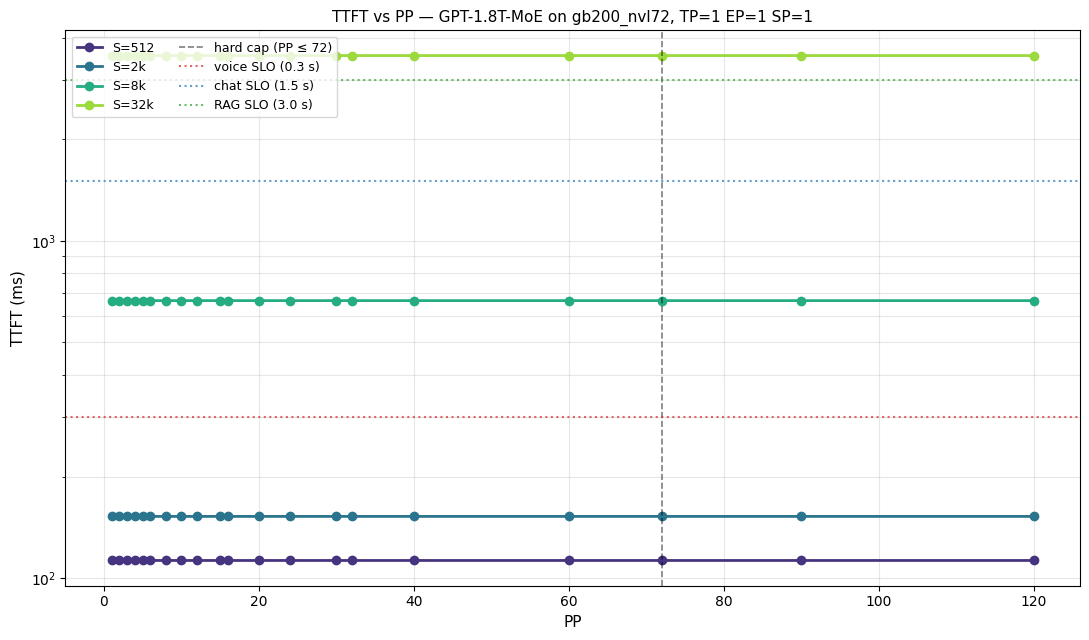

In [6]:
fig, ax = plt.subplots(figsize=(11, 6.5))

cmap = plt.get_cmap("viridis")
for i, s in enumerate(S_INPUT_LIST):
    color = cmap(0.15 + 0.7 * i / max(1, len(S_INPUT_LIST) - 1))
    ttfts_ms = [ttft_grid[(pp, s)] * 1000 for pp in PP_TTFT_SWEEP]
    label = f"S={s if s < 1024 else f'{s//1024}k'}"
    ax.plot(PP_TTFT_SWEEP, ttfts_ms, "o-", color=color, label=label, lw=2)

# Vertical line at the hard cap to show the cluster/fabric/architectural ceiling
ax.axvline(PP_HARD_CAP, color="k", linestyle="--", alpha=0.5, lw=1.2,
           label=f"hard cap (PP ≤ {PP_HARD_CAP})")

slo_colors = {"voice": "#d62728", "chat": "#1f77b4", "RAG": "#2ca02c"}
for w in WORKLOADS:
    if w.ttft_slo_ms == float("inf"):
        continue
    ax.axhline(w.ttft_slo_ms, color=slo_colors.get(w.name, "k"),
               linestyle=":", alpha=0.7, lw=1.5,
               label=f"{w.name} SLO ({w.ttft_slo_ms/1000:.1f} s)")

ax.set_xlabel("PP", fontsize=11)
ax.set_ylabel("TTFT (ms)", fontsize=11)
ax.set_yscale("log")
ax.set_title(f"TTFT vs PP — {model.name} on {system.name}, "
             f"TP={TP_FIX} EP={EP_FIX} SP={SP_FIX}", fontsize=11)
ax.legend(loc="upper left", fontsize=9, ncol=2)
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()


## 5. Stacked summary — binding constraint per workload

For each workload class, derive `PP_max = min(architectural, cluster, fabric, bubble, TTFT)`. The TTFT cap depends on `S_input` — we report it for the most demanding `S_input` the workload typically sees:

- voice → 512 (short utterances)
- chat → 2k (typical message + history)
- RAG → 8k (retrieved context + question)
- batch → 32k (long-doc / agentic)


In [7]:
@dataclass
class WorkloadProfile:
    workload: Workload
    typical_s_input: int


PROFILES = [
    WorkloadProfile(WORKLOADS[0], typical_s_input=512),
    WorkloadProfile(WORKLOADS[1], typical_s_input=2048),
    WorkloadProfile(WORKLOADS[2], typical_s_input=8192),
    WorkloadProfile(WORKLOADS[3], typical_s_input=32768),
]


def pp_max_ttft(workload: Workload, s_input: int) -> int:
    """Largest PP whose TTFT stays under workload's SLO at the given S_input.

    Uses the FULL architectural sweep (PP up to L), not the hard-cap-filtered
    set, so the TTFT cap is independent of the cluster/fabric caps.
    """
    if workload.ttft_slo_ms == float("inf"):
        return L
    candidates = [pp for pp in PP_TTFT_SWEEP
                  if ttft_grid.get((pp, s_input), float("inf")) * 1000 <= workload.ttft_slo_ms]
    return max(candidates) if candidates else 0


print(f"{'workload':10s} {'S_in':>6s} | "
      f"{'arch':>5s} {'cluster':>8s} {'fabric':>7s} {'bubble':>7s} {'TTFT':>5s} | "
      f"{'PP_max':>7s}  {'binds':>14s}")
print("-" * 84)
for prof in PROFILES:
    w = prof.workload
    bounds = {
        "arch": L,
        "cluster": cluster_cap,
        "fabric": pp_fabric_radix,
        "bubble": w.B_sustained_min,
        "TTFT": pp_max_ttft(w, prof.typical_s_input),
    }
    pp_max = min(bounds.values())
    binds = ",".join(k for k, v in bounds.items() if v == pp_max)
    print(f"{w.name:10s} {prof.typical_s_input:>6d} | "
          f"{bounds['arch']:>5d} {bounds['cluster']:>8d} {bounds['fabric']:>7d} "
          f"{bounds['bubble']:>7d} {bounds['TTFT']:>5d} | "
          f"{pp_max:>7d}  {binds:>14s}")


workload     S_in |  arch  cluster  fabric  bubble  TTFT |  PP_max           binds
------------------------------------------------------------------------------------
voice         512 |   120       72      72       4   120 |       4          bubble
chat         2048 |   120       72      72      16   120 |      16          bubble
RAG          8192 |   120       72      72      32   120 |      32          bubble
batch       32768 |   120       72      72     128   120 |      72  cluster,fabric


## 7. Prefill cluster (disaggregated TTFT)

Now we treat prefill and decode as **separate clusters** with mismatched partitions. The decode cluster runs the production-typical decode-Pareto (`PP=8 TP=8 EP=1 SP=1` from `ttft_vs_io.ipynb`). The prefill cluster picks its own partition, with PP free to vary in the ceiling case (`TP=EP=SP=1`).

This changes the constraint stack:
- **Bubble cap → N/A.** Prefill is one-shot per request, no in-flight pipelining bubble.
- **TTFT cap now includes the disaggregation handoff** (`α_inter + M_KV / BW_inter + repack`). Even if prefill compute is PP-invariant, the handoff cost is a constant overhead added on top.
- **Hard caps** (architectural, cluster shape, fabric) still apply.

Disagg defaults below assume an intra-rack-class inter-cluster link (NVLink5 BW, ~5 μs α) — loosen for cross-rack or cross-DC scenarios.


In [8]:
from llm_perf import InferenceCalculator
from llm_perf.calculators.e2e_calculator import E2ECalculator
from llm_perf.specs.disagg_spec import DisaggSpec
from llm_perf.specs.overhead_spec import OverheadSpec
from llm_perf.specs.system_spec import span_tiers

# Decode cluster — fixed at production-typical Pareto winner
DECODE_PART = PartitionSpec(PP=8, TP=8, EP=1, SP=1)

# Disagg handoff defaults (intra-rack-class; loosen for cross-DC)
_, INTRA_BW_GBps, _ = span_tiers(system.get_tier_chain('TP'), 2)
INTER_BW_GBps   = INTRA_BW_GBps   # NVLink5-class inter-cluster link
INTER_ALPHA_US  = 5.0             # one round-trip
REPACK_BW_GBps  = INTRA_BW_GBps   # decode-side scale-up BW
REPACK_ETA      = 1.5             # mismatch reshuffle tax
OVERLAP_RHO_KV  = 0.0             # no overlap with prefill

decode_gpus = DECODE_PART.PP * DECODE_PART.TP * DECODE_PART.EP * DECODE_PART.SP
print(f"Decode partition: PP={DECODE_PART.PP} TP={DECODE_PART.TP} "
      f"EP={DECODE_PART.EP} SP={DECODE_PART.SP}  ({decode_gpus} GPUs)")
print(f"Disagg: inter_BW={INTER_BW_GBps:.0f} GB/s  α={INTER_ALPHA_US:.1f} μs  "
      f"repack_BW={REPACK_BW_GBps:.0f} GB/s  η={REPACK_ETA:.1f}")


Decode partition: PP=8 TP=8 EP=1 SP=1  (64 GPUs)
Disagg: inter_BW=900 GB/s  α=5.0 μs  repack_BW=900 GB/s  η=1.5


In [9]:
def compute_ttft_disagg(pp_pf: int, s_input: int) -> float:
    """Disaggregated TTFT for prefill cluster at PP_pf, fixed decode partition."""
    tuner = deepcopy(tuner_base)
    tuner.S_input = s_input
    pf_part = PartitionSpec(PP=pp_pf, TP=TP_FIX, EP=EP_FIX, SP=SP_FIX)

    pf_res = PrefillCalculator(model, system, pf_part, tuner).run()
    dec_res = InferenceCalculator(model, system, DECODE_PART, tuner).run()

    disagg = DisaggSpec(
        disaggregated=True,
        inter_alpha_us=INTER_ALPHA_US,
        inter_bandwidth_GBps=INTER_BW_GBps,
        repack_GBps=REPACK_BW_GBps,
        repack_eta=REPACK_ETA,
        overlap_rho_KV=OVERLAP_RHO_KV,
    )

    e2e = E2ECalculator(
        dec_res, pf_res, OverheadSpec(), disagg,
        model, system, DECODE_PART, tuner,
    ).run()
    return e2e.TTFT


# Disaggregated TTFT grid — same PP × S sweep as §4, with handoff overhead
ttft_pf_grid: dict[tuple[int, int], float] = {}
for pp in PP_TTFT_SWEEP:
    for s in S_INPUT_LIST:
        ttft_pf_grid[(pp, s)] = compute_ttft_disagg(pp, s)

print(f"{'PP':>4s}  " + "  ".join(f"S={s:>5d}" for s in S_INPUT_LIST))
print("-" * (8 + 11 * len(S_INPUT_LIST)))
for pp in PP_TTFT_SWEEP:
    row = f"{pp:>4d}  "
    for s in S_INPUT_LIST:
        row += f"{ttft_pf_grid[(pp, s)]*1000:>7.0f} ms  "
    print(row)


  PP  S=  512  S= 2048  S= 8192  S=32768
----------------------------------------------------
   1      134 ms      174 ms      692 ms     3585 ms  
   2      134 ms      174 ms      692 ms     3586 ms  
   3      134 ms      174 ms      692 ms     3586 ms  
   4      134 ms      174 ms      692 ms     3586 ms  
   5      134 ms      174 ms      692 ms     3586 ms  
   6      134 ms      174 ms      692 ms     3586 ms  
   8      134 ms      174 ms      692 ms     3586 ms  
  10      134 ms      174 ms      692 ms     3586 ms  
  12      134 ms      174 ms      692 ms     3586 ms  
  15      134 ms      174 ms      692 ms     3586 ms  
  16      134 ms      174 ms      692 ms     3586 ms  
  20      134 ms      174 ms      692 ms     3586 ms  
  24      134 ms      174 ms      692 ms     3586 ms  
  30      134 ms      174 ms      692 ms     3586 ms  
  32      134 ms      174 ms      692 ms     3586 ms  
  40      134 ms      174 ms      692 ms     3586 ms  
  60      134 ms      174 

### TTFT vs PP_pf — disagg (solid) vs unified reference (dashed)

Solid lines = disaggregated TTFT (with handoff). Dashed lines = the unified-cluster TTFT from §4 for the same `S_input`. The vertical gap between solid and dashed is the handoff overhead — roughly constant in PP for a given S_input.


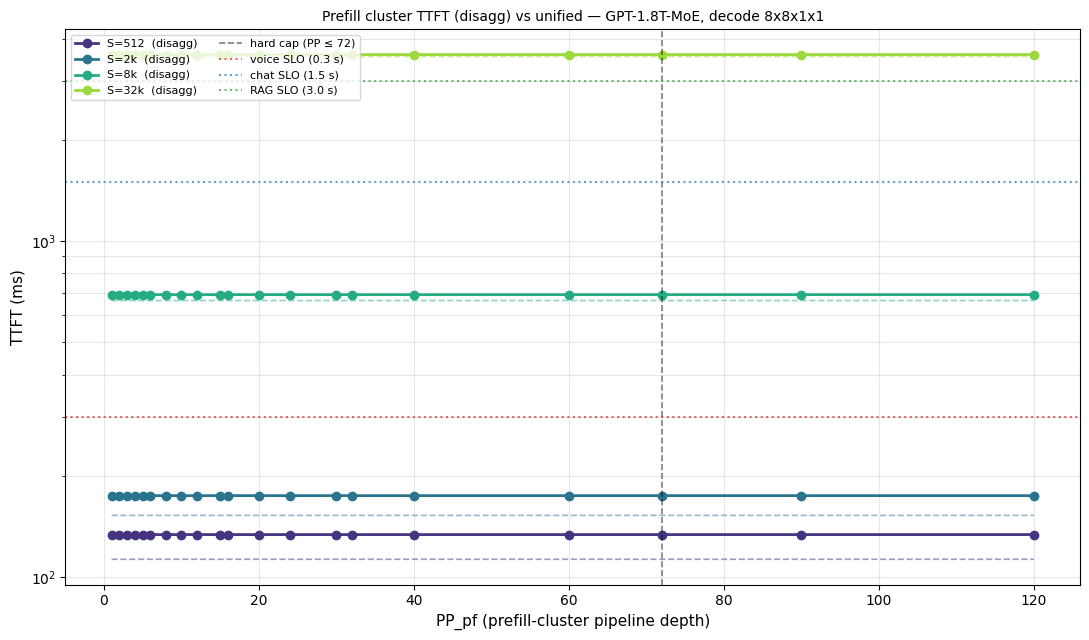

In [10]:
fig, ax = plt.subplots(figsize=(11, 6.5))

cmap = plt.get_cmap("viridis")
for i, s in enumerate(S_INPUT_LIST):
    color = cmap(0.15 + 0.7 * i / max(1, len(S_INPUT_LIST) - 1))
    ttfts_ms = [ttft_pf_grid[(pp, s)] * 1000 for pp in PP_TTFT_SWEEP]
    label = f"S={s if s < 1024 else f'{s//1024}k'}  (disagg)"
    ax.plot(PP_TTFT_SWEEP, ttfts_ms, "o-", color=color, label=label, lw=2)
    ttfts_ref = [ttft_grid[(pp, s)] * 1000 for pp in PP_TTFT_SWEEP]
    ax.plot(PP_TTFT_SWEEP, ttfts_ref, "--", color=color, alpha=0.5, lw=1.2)

ax.axvline(PP_HARD_CAP, color="k", linestyle="--", alpha=0.5, lw=1.2,
           label=f"hard cap (PP ≤ {PP_HARD_CAP})")

slo_colors = {"voice": "#d62728", "chat": "#1f77b4", "RAG": "#2ca02c"}
for w in WORKLOADS:
    if w.ttft_slo_ms == float("inf"):
        continue
    ax.axhline(w.ttft_slo_ms, color=slo_colors.get(w.name, "k"),
               linestyle=":", alpha=0.7, lw=1.5,
               label=f"{w.name} SLO ({w.ttft_slo_ms/1000:.1f} s)")

ax.set_xlabel("PP_pf (prefill-cluster pipeline depth)", fontsize=11)
ax.set_ylabel("TTFT (ms)", fontsize=11)
ax.set_yscale("log")
ax.set_title(f"Prefill cluster TTFT (disagg) vs unified — {model.name}, "
             f"decode {DECODE_PART.PP}x{DECODE_PART.TP}x{DECODE_PART.EP}x{DECODE_PART.SP}",
             fontsize=10)
ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()


## 8. Stacked summary — prefill cluster

Same workload-class breakdown as §5, but with the **bubble column removed** (prefill has no in-flight bubble) and the TTFT column based on the **disaggregated** TTFT (prefill + handoff + first-token).


In [11]:
def pp_max_ttft_pf(workload: Workload, s_input: int) -> int:
    if workload.ttft_slo_ms == float("inf"):
        return L
    candidates = [pp for pp in PP_TTFT_SWEEP
                  if ttft_pf_grid.get((pp, s_input), float("inf")) * 1000 <= workload.ttft_slo_ms]
    return max(candidates) if candidates else 0


print(f"{'workload':10s} {'S_in':>6s} | "
      f"{'arch':>5s} {'cluster':>8s} {'fabric':>7s} {'TTFT':>5s} | "
      f"{'PP_max':>7s}  {'binds':>14s}")
print("-" * 76)
for prof in PROFILES:
    w = prof.workload
    bounds = {
        "arch": L,
        "cluster": cluster_cap,
        "fabric": pp_fabric_radix,
        "TTFT": pp_max_ttft_pf(w, prof.typical_s_input),
    }
    pp_max = min(bounds.values())
    binds = ",".join(k for k, v in bounds.items() if v == pp_max)
    print(f"{w.name:10s} {prof.typical_s_input:>6d} | "
          f"{bounds['arch']:>5d} {bounds['cluster']:>8d} {bounds['fabric']:>7d} {bounds['TTFT']:>5d} | "
          f"{pp_max:>7d}  {binds:>14s}")


workload     S_in |  arch  cluster  fabric  TTFT |  PP_max           binds
----------------------------------------------------------------------------
voice         512 |   120       72      72   120 |      72  cluster,fabric
chat         2048 |   120       72      72   120 |      72  cluster,fabric
RAG          8192 |   120       72      72   120 |      72  cluster,fabric
batch       32768 |   120       72      72   120 |      72  cluster,fabric


## 9. Decode cluster under realistic disaggregation (50 GB/s link)

The §7–§8 disagg used a 900 GB/s NVLink-class inter-cluster link, which is unrealistic for actual disaggregated deployments — those typically span racks via InfiniBand or RoCE at **50 GB/s class** with a ~50 μs per-RDMA-WR α. This section redoes the analysis under that link assumption and looks at the **decode cluster** PP (not prefill PP):

- **Prefill cluster fixed** at its ceiling-case optimum from §7 (`PP_pf = 72, TP=EP=SP=1`).
- **Decode cluster varies PP** in its own ceiling case (`TP_dec=EP_dec=SP_dec=1`).
- **Inter-cluster link** = 50 GB/s, α = 50 μs.
- **Bubble cap returns** — the decode cluster runs the autoregressive pipeline, so `PP_dec ≤ B_sustained_min` still applies.
- **TTFT cap** uses the disagg formula with the slow link, so the handoff term `M_KV / 50 GB/s` becomes substantial for long prompts.


In [12]:
INTER_BW_REALISTIC = 50.0       # IB / RoCE class
INTER_ALPHA_REALISTIC = 50.0    # typical RDMA round-trip

# Prefill cluster fixed at its §8 ceiling: PP_pf = hard cap, TP=EP=SP=1
PREFILL_PART_FIXED = PartitionSpec(PP=PP_HARD_CAP, TP=1, EP=1, SP=1)


def compute_ttft_decode_disagg(pp_dec: int, s_input: int) -> float:
    """User-visible TTFT in the decode cluster under realistic 50 GB/s disaggregation."""
    tuner = deepcopy(tuner_base)
    tuner.S_input = s_input
    dec_part = PartitionSpec(PP=pp_dec, TP=TP_FIX, EP=EP_FIX, SP=SP_FIX)

    pf_res = PrefillCalculator(model, system, PREFILL_PART_FIXED, tuner).run()
    dec_res = InferenceCalculator(model, system, dec_part, tuner).run()

    disagg = DisaggSpec(
        disaggregated=True,
        inter_alpha_us=INTER_ALPHA_REALISTIC,
        inter_bandwidth_GBps=INTER_BW_REALISTIC,
        repack_GBps=REPACK_BW_GBps,
        repack_eta=REPACK_ETA,
        overlap_rho_KV=OVERLAP_RHO_KV,
    )

    e2e = E2ECalculator(
        dec_res, pf_res, OverheadSpec(), disagg,
        model, system, dec_part, tuner,
    ).run()
    return e2e.TTFT


ttft_dec_grid: dict[tuple[int, int], float] = {}
for pp in PP_TTFT_SWEEP:
    for s in S_INPUT_LIST:
        ttft_dec_grid[(pp, s)] = compute_ttft_decode_disagg(pp, s)

print(f"Prefill cluster fixed at PP_pf={PREFILL_PART_FIXED.PP}, TP=EP=SP=1")
print(f"Decode cluster varies PP, TP=EP=SP=1, link=50 GB/s, α=50 μs\n")

print(f"{'PP_dec':>6s}  " + "  ".join(f"S={s:>5d}" for s in S_INPUT_LIST))
print("-" * (10 + 11 * len(S_INPUT_LIST)))
for pp in PP_TTFT_SWEEP:
    row = f"{pp:>6d}  "
    for s in S_INPUT_LIST:
        row += f"{ttft_dec_grid[(pp, s)]*1000:>7.0f} ms  "
    print(row)


Prefill cluster fixed at PP_pf=72, TP=EP=SP=1
Decode cluster varies PP, TP=EP=SP=1, link=50 GB/s, α=50 μs

PP_dec  S=  512  S= 2048  S= 8192  S=32768
------------------------------------------------------
     1      239 ms      289 ms      842 ms     3878 ms  
     2      239 ms      289 ms      842 ms     3878 ms  
     3      239 ms      289 ms      842 ms     3878 ms  
     4      239 ms      289 ms      842 ms     3878 ms  
     5      239 ms      289 ms      842 ms     3878 ms  
     6      239 ms      289 ms      842 ms     3878 ms  
     8      239 ms      289 ms      842 ms     3878 ms  
    10      239 ms      289 ms      842 ms     3878 ms  
    12      239 ms      289 ms      842 ms     3878 ms  
    15      239 ms      289 ms      842 ms     3878 ms  
    16      239 ms      289 ms      842 ms     3878 ms  
    20      239 ms      289 ms      842 ms     3878 ms  
    24      239 ms      289 ms      842 ms     3878 ms  
    30      239 ms      289 ms      842 ms     3878 ms

### TTFT vs PP_dec — three scenarios overlaid

- **Solid:** realistic disagg (50 GB/s link)
- **Dash-dot:** optimistic disagg from §7 (900 GB/s link)
- **Dashed:** unified reference from §4

The vertical gaps show how much the inter-cluster link speed costs in user-visible TTFT.


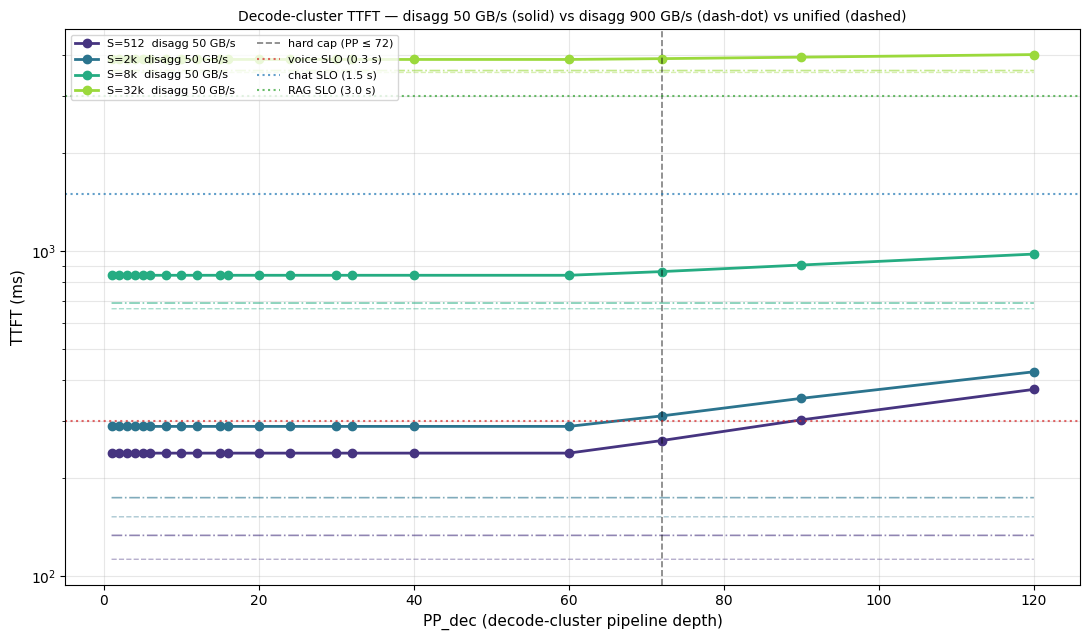

In [13]:
fig, ax = plt.subplots(figsize=(11, 6.5))

cmap = plt.get_cmap("viridis")
for i, s in enumerate(S_INPUT_LIST):
    color = cmap(0.15 + 0.7 * i / max(1, len(S_INPUT_LIST) - 1))
    s_label = f"S={s if s < 1024 else f'{s//1024}k'}"

    ax.plot(PP_TTFT_SWEEP, [ttft_dec_grid[(pp, s)] * 1000 for pp in PP_TTFT_SWEEP],
            "o-", color=color, label=f"{s_label}  disagg 50 GB/s", lw=2)
    ax.plot(PP_TTFT_SWEEP, [ttft_pf_grid[(pp, s)] * 1000 for pp in PP_TTFT_SWEEP],
            "-.", color=color, alpha=0.6, lw=1.2)
    ax.plot(PP_TTFT_SWEEP, [ttft_grid[(pp, s)] * 1000 for pp in PP_TTFT_SWEEP],
            "--", color=color, alpha=0.4, lw=1.0)

ax.axvline(PP_HARD_CAP, color="k", linestyle="--", alpha=0.5, lw=1.2,
           label=f"hard cap (PP ≤ {PP_HARD_CAP})")

slo_colors = {"voice": "#d62728", "chat": "#1f77b4", "RAG": "#2ca02c"}
for w in WORKLOADS:
    if w.ttft_slo_ms == float("inf"):
        continue
    ax.axhline(w.ttft_slo_ms, color=slo_colors.get(w.name, "k"),
               linestyle=":", alpha=0.7, lw=1.5,
               label=f"{w.name} SLO ({w.ttft_slo_ms/1000:.1f} s)")

ax.set_xlabel("PP_dec (decode-cluster pipeline depth)", fontsize=11)
ax.set_ylabel("TTFT (ms)", fontsize=11)
ax.set_yscale("log")
ax.set_title(f"Decode-cluster TTFT — disagg 50 GB/s (solid) vs disagg 900 GB/s (dash-dot) "
             f"vs unified (dashed)", fontsize=10)
ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()


### Stacked summary — decode cluster under realistic disagg

Bubble cap returns (this is the decode side), and TTFT now uses the 50 GB/s disagg formula. The combination tells you the actual decode-cluster PP_max for production.


In [14]:
def pp_max_ttft_dec(workload: Workload, s_input: int) -> int:
    if workload.ttft_slo_ms == float("inf"):
        return L
    candidates = [pp for pp in PP_TTFT_SWEEP
                  if ttft_dec_grid.get((pp, s_input), float("inf")) * 1000 <= workload.ttft_slo_ms]
    return max(candidates) if candidates else 0


print(f"{'workload':10s} {'S_in':>6s} | "
      f"{'arch':>5s} {'cluster':>8s} {'fabric':>7s} {'bubble':>7s} {'TTFT':>5s} | "
      f"{'PP_max':>7s}  {'binds':>14s}")
print("-" * 84)
for prof in PROFILES:
    w = prof.workload
    bounds = {
        "arch": L,
        "cluster": cluster_cap,
        "fabric": pp_fabric_radix,
        "bubble": w.B_sustained_min,
        "TTFT": pp_max_ttft_dec(w, prof.typical_s_input),
    }
    pp_max = min(bounds.values())
    binds = ",".join(k for k, v in bounds.items() if v == pp_max)
    print(f"{w.name:10s} {prof.typical_s_input:>6d} | "
          f"{bounds['arch']:>5d} {bounds['cluster']:>8d} {bounds['fabric']:>7d} "
          f"{bounds['bubble']:>7d} {bounds['TTFT']:>5d} | "
          f"{pp_max:>7d}  {binds:>14s}")


workload     S_in |  arch  cluster  fabric  bubble  TTFT |  PP_max           binds
------------------------------------------------------------------------------------
voice         512 |   120       72      72       4    72 |       4          bubble
chat         2048 |   120       72      72      16   120 |      16          bubble
RAG          8192 |   120       72      72      32   120 |      32          bubble
batch       32768 |   120       72      72     128   120 |      72  cluster,fabric


## 10. Takeaways

### Unified deployment (§2–§5)

1. **In the ceiling case (TP=EP=SP=1), bubble is the dominant binding constraint** for any workload with `B_sustained_min < scale_up_radix`. Voice (B=4) caps PP at 4; chat (B=16) at 16; RAG (B=32) at 32. Only batch-tier workloads (B ≥ 128) can use the full hard-cap PP.
2. **Cluster-shape becomes binding the moment you raise TP, EP, or SP.** Switching to `(TP, EP, SP) = (8, 1, 1)` drops the cluster cap from 72 → 9, dwarfing every other constraint. Most production deployments live in this regime — bubble matters less because cluster has already clipped PP below it.
3. **TTFT rarely binds for compute-bound prefill on Blackwell-class hardware**, because the per-stage cost shrinks as `1/PP` and the warmup `(PP-1) × t_stage` stays roughly constant. TTFT actually *decreases slightly* with deeper PP (smaller per-stage payloads → cheaper collectives). TTFT only becomes a real ceiling for very small models or very long prompts on slower hardware.
4. **Architectural and fabric-tier caps rarely bind in current production.** Modern transformers have `L ≥ 60` and NVL72 has 72-port radix — these only matter for very small models (Llama-3-8B style) or PP that crosses NVL72 racks (NVL576+).

### Prefill cluster, optimistic 900 GB/s link (§7–§8)

5. **Removing bubble unlocks deeper PP for low-batch workloads.** Voice / chat / RAG were capped by bubble at 4 / 16 / 32 in the unified view; the prefill cluster removes that cap entirely. The new ceiling is whichever of `{cluster, fabric, TTFT}` binds first.
6. **Handoff overhead is roughly PP-invariant** — it depends on `M_KV` (set by `S_input` and KV-head count) and `BW_inter`, neither of which scales with prefill PP. The disagg curve sits as a near-constant offset above the unified curve.
7. **TTFT becomes the real binding constraint for the prefill cluster** at long prompts. Even though prefill compute is PP-invariant, the absolute TTFT at large `S_input` (e.g., 32k) can exceed strict SLOs (e.g., RAG's 3 s) regardless of PP — meaning the model/system pair is fundamentally too slow for that workload class, not that there's a "right" PP.

### Decode cluster, realistic 50 GB/s disagg (§9)

8. **The 50 GB/s link adds a meaningful per-request handoff** that scales with `S_input × L × n_kv` — for short prompts it's a small overhead on top of prefill; for long prompts it becomes the dominant TTFT term. Compare the solid (50 GB/s) vs dash-dot (900 GB/s) curves in §9 — the gap is purely the link cost.
9. **The decode cluster's bubble cap returns** under disaggregation — the bubble lives wherever the autoregressive pipeline runs. So PP_dec is bounded the same way as the unified §5 view, just with a higher TTFT floor.
10. **Disaggregation is worth it when** decode-side PP is forced shallow by bubble (low B_sustained_min) AND prefill would benefit from a much wider/different partition. The 50 GB/s handoff is the price you pay; whether it's worth it depends on how much your prefill-side compute amortizes vs how much your decode-side bubble would have cost in the unified view — `ttft_vs_io.ipynb` quantifies that trade.

### To re-run for a different scenario

- Swap `MODEL`, `SYSTEM`, `TUNER` in section 1.
- Adjust `TP_FIX, EP_FIX, SP_FIX` (default ceiling case) to model a specific prefill-cluster shape.
- Adjust `DECODE_PART` in section 7 to a different decode-side baseline.
- Adjust `INTER_BW_GBps` / `INTER_ALPHA_US` in section 7 (optimistic 900 GB/s) or `INTER_BW_REALISTIC` / `INTER_ALPHA_REALISTIC` in section 9 (50 GB/s default) for different inter-cluster link assumptions.
- Edit the `WORKLOADS` list to add or change SLOs / `B_sustained_min` values.
- Edit `S_INPUT_LIST` to sweep different prompt lengths.
